In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

AttributeError: partially initialized module 'pandas' has no attribute 'core' (most likely due to a circular import)

In [57]:
Fire_detection_data=pd.read_csv("realistic_forest_fire_dataset.csv")

In [58]:
Fire_detection_data

,Temperature (°C),Relative Humidity (%),Wind Speed (km/h),FFMC,Topography,Lightning Activity,Oxygen (%),Human Activity,Probability of Forest Fire (%)
0,42.4,16,42.0,100.0,Flat,NaN,20.36,Low,94.1
1,30.2,36,34.0,72.7,Mountain,Moderate,19.89,High,90.0
2,31.5,34,6.0,84.7,Hill,Moderate,20.27,High,70.0
3,37.6,12,56.0,100.0,Hill,Severe,20.37,Medium,100.0
4,36.7,17,38.7,98.9,Hill,Moderate,19.36,Medium,99.2
...,...,...,...,...,...,...,...,...,...
795,21.8,47,22.5,60.0,Flat,NaN,20.15,Low,41.4
796,36.7,26,38.6,98.3,Hill,Severe,19.47,Low,95.5
797,20.6,58,42.5,60.0,Flat,NaN,19.60,Medium,61.5
798,37.4,12,10.8,100.0,Flat,Moderate,19.42,High,89.7


In [59]:
Fire_detection_data.describe()

,Temperature (°C),Relative Humidity (%),Wind Speed (km/h),FFMC,Oxygen (%),Probability of Forest Fire (%)
count,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,32.456375,31.505000,32.381250,82.984375,19.968412,79.656000
std,7.346678,13.572315,15.983621,16.212074,0.577273,17.672089
min,20.000000,10.000000,5.000000,60.000000,19.010000,26.800000
25%,26.400000,20.750000,18.475000,65.575000,19.470000,66.500000
50%,32.450000,30.000000,32.650000,86.900000,19.925000,82.900000
75%,38.825000,42.000000,46.625000,100.000000,20.460000,95.925000
max,45.000000,65.000000,59.900000,100.000000,21.000000,100.000000


In [60]:
Fire_detection_data.isnull().sum()

Temperature (°C)                    0
Relative Humidity (%)               0
Wind Speed (km/h)                   0
FFMC                                0
Topography                          0
Lightning Activity                257
Oxygen (%)                          0
Human Activity                     68
Probability of Forest Fire (%)      0
dtype: int64

In [61]:
Fire_detection_data=Fire_detection_data.fillna("None")

In [62]:
Fire_detection_data

,Temperature (°C),Relative Humidity (%),Wind Speed (km/h),FFMC,Topography,Lightning Activity,Oxygen (%),Human Activity,Probability of Forest Fire (%)
0,42.4,16,42.0,100.0,Flat,None,20.36,Low,94.1
1,30.2,36,34.0,72.7,Mountain,Moderate,19.89,High,90.0
2,31.5,34,6.0,84.7,Hill,Moderate,20.27,High,70.0
3,37.6,12,56.0,100.0,Hill,Severe,20.37,Medium,100.0
4,36.7,17,38.7,98.9,Hill,Moderate,19.36,Medium,99.2
...,...,...,...,...,...,...,...,...,...
795,21.8,47,22.5,60.0,Flat,None,20.15,Low,41.4
796,36.7,26,38.6,98.3,Hill,Severe,19.47,Low,95.5
797,20.6,58,42.5,60.0,Flat,None,19.60,Medium,61.5
798,37.4,12,10.8,100.0,Flat,Moderate,19.42,High,89.7


In [63]:
from sklearn.preprocessing import OneHotEncoder
def one_hot_encoding(df,column_name):
    encoder=OneHotEncoder(sparse_output=False)
    Encoded_array=encoder.fit_transform(df[[column_name]])
    Encoded_Data_frame=pd.DataFrame(Encoded_array,columns=encoder.get_feature_names_out([column_name]))
    df=df.drop(column_name,axis=1)
    df=pd.concat([df,Encoded_Data_frame],axis=1)
    print(Encoded_Data_frame)
    return df
Fire_detection_data=one_hot_encoding(Fire_detection_data,"Topography")
Fire_detection_data=one_hot_encoding(Fire_detection_data,"Lightning Activity")
Fire_detection_data=one_hot_encoding(Fire_detection_data,"Human Activity")

     Topography_Flat  Topography_Hill  Topography_Mountain
0                1.0              0.0                  0.0
1                0.0              0.0                  1.0
2                0.0              1.0                  0.0
3                0.0              1.0                  0.0
4                0.0              1.0                  0.0
..               ...              ...                  ...
795              1.0              0.0                  0.0
796              0.0              1.0                  0.0
797              1.0              0.0                  0.0
798              1.0              0.0                  0.0
799              1.0              0.0                  0.0

[800 rows x 3 columns]
     Lightning Activity_Moderate  Lightning Activity_None  \
0                            0.0                      1.0   
1                            1.0                      0.0   
2                            1.0                      0.0   
3                       

In [64]:
Fire_detection_data

,Temperature (°C),Relative Humidity (%),Wind Speed (km/h),FFMC,Oxygen (%),Probability of Forest Fire (%),Topography_Flat,Topography_Hill,Topography_Mountain,Lightning Activity_Moderate,Lightning Activity_None,Lightning Activity_Severe,Human Activity_High,Human Activity_Low,Human Activity_Medium,Human Activity_None
0,42.4,16,42.0,100.0,20.36,94.1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,30.2,36,34.0,72.7,19.89,90.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
2,31.5,34,6.0,84.7,20.27,70.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3,37.6,12,56.0,100.0,20.37,100.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,36.7,17,38.7,98.9,19.36,99.2,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,21.8,47,22.5,60.0,20.15,41.4,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
796,36.7,26,38.6,98.3,19.47,95.5,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
797,20.6,58,42.5,60.0,19.60,61.5,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
798,37.4,12,10.8,100.0,19.42,89.7,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


In [65]:
x=Fire_detection_data.drop("Probability of Forest Fire (%)",axis=1)
y=Fire_detection_data["Probability of Forest Fire (%)"]

In [66]:
print(x)
print(y)

     Temperature (°C)  Relative Humidity (%)  Wind Speed (km/h)   FFMC  \
0                42.4                     16               42.0  100.0   
1                30.2                     36               34.0   72.7   
2                31.5                     34                6.0   84.7   
3                37.6                     12               56.0  100.0   
4                36.7                     17               38.7   98.9   
..                ...                    ...                ...    ...   
795              21.8                     47               22.5   60.0   
796              36.7                     26               38.6   98.3   
797              20.6                     58               42.5   60.0   
798              37.4                     12               10.8  100.0   
799              43.0                     24               52.6  100.0   

     Oxygen (%)  Topography_Flat  Topography_Hill  Topography_Mountain  \
0         20.36              1.0     

In [67]:
from sklearn.model_selection import train_test_split
x_train,x_val,y_train,y_val=train_test_split(x,y,test_size=0.2,random_state=42)

In [68]:
print(x_train.shape)
print(y_train.shape)
print(x_val.shape)
print(y_val.shape)

(640, 15)
(640,)
(160, 15)
(160,)


In [69]:
from sklearn.ensemble import RandomForestRegressor
model=RandomForestRegressor()


In [70]:
model.fit(x_train,y_train)

RandomForestRegressor()

In [71]:
model.score(x_val,y_val)

0.9163287680114738

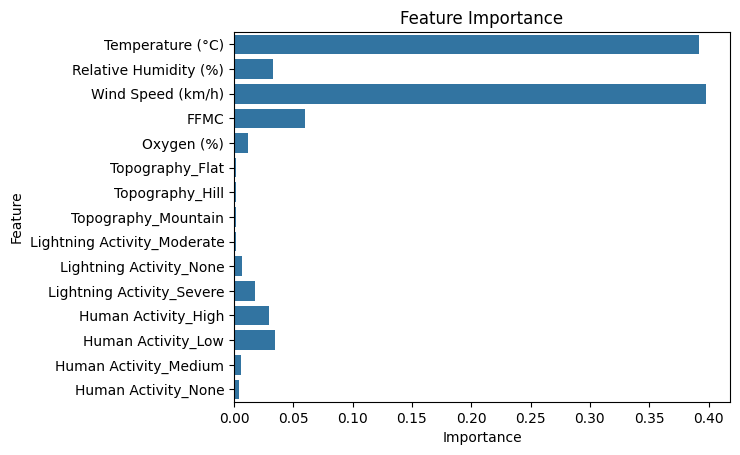

In [72]:
# Plot feature importance
importances = model.feature_importances_
features = x.columns

sns.barplot(x=importances, y=features)
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()


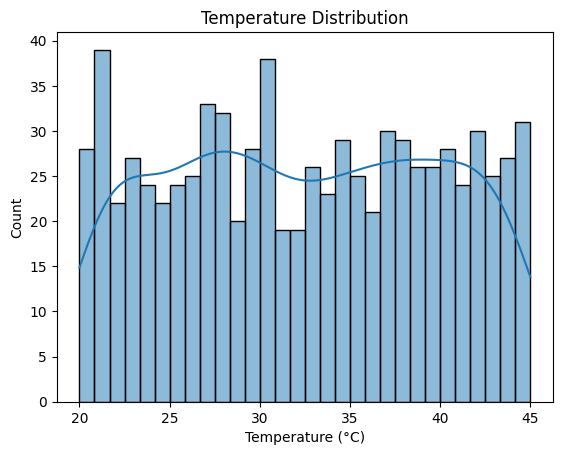

In [73]:


# Example: Temperature Distribution from Fire_detection_data
sns.histplot(Fire_detection_data['Temperature (°C)'], kde=True, bins=30)
plt.title('Temperature Distribution')
plt.xlabel('Temperature (°C)')
plt.show()


In [74]:
y_pred=model.predict(x_val)

In [75]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error, median_absolute_error
mae=mean_absolute_error(y_val,y_pred)
mse=mean_squared_error(y_val,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_val,y_pred)
mape=mean_absolute_percentage_error(y_val,y_pred)
medae=median_absolute_error(y_val,y_pred)


In [76]:
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-Squared (R²): {r2:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.4f}")
print(f"Median Absolute Error (MedAE): {medae:.4f}")

Mean Absolute Error (MAE): 3.9241
Mean Squared Error (MSE): 25.7792
Root Mean Squared Error (RMSE): 5.0773
R-Squared (R²): 0.9163
Mean Absolute Percentage Error (MAPE): 0.0523
Median Absolute Error (MedAE): 2.9540


In [77]:
y_pred


array([ 55.84 ,  67.786,  48.13 ,  66.867,  86.596,  69.524,  41.473,
        48.407,  69.994,  98.536,  48.318,  82.458,  96.997,  95.093,
        71.642,  92.396,  81.541,  63.169,  63.695,  68.536,  86.325,
        99.456,  97.776,  77.193,  94.563,  76.964,  81.955,  78.994,
        90.588,  87.813,  80.169,  98.428,  70.466,  88.662,  56.471,
        94.231,  80.226,  66.795,  96.246,  58.493,  77.063,  71.549,
        98.247,  53.844,  98.461,  65.083,  78.3  ,  94.977,  88.789,
        67.092,  97.983,  97.585,  77.558,  89.021,  47.07 ,  84.948,
        63.394,  91.608,  52.572,  88.319,  94.895,  98.946,  93.907,
        68.918,  69.743,  85.973,  44.352,  79.002,  60.306,  98.938,
        87.569,  69.102,  45.862,  85.535,  93.592,  59.874,  68.835,
        67.687,  82.575,  74.23 ,  99.574,  82.049,  76.766,  80.254,
        99.925,  64.645,  65.28 ,  92.413, 100.   ,  94.247,  74.949,
        82.47 ,  96.28 ,  48.957,  61.449,  87.238,  73.978,  65.211,
        88.51 ,  93.

In [78]:
y_val

696     55.2
667     65.3
63      46.9
533     79.7
66      75.8
       ...  
589     79.9
798     89.7
744     87.4
513    100.0
670     83.5
Name: Probability of Forest Fire (%), Length: 160, dtype: float64

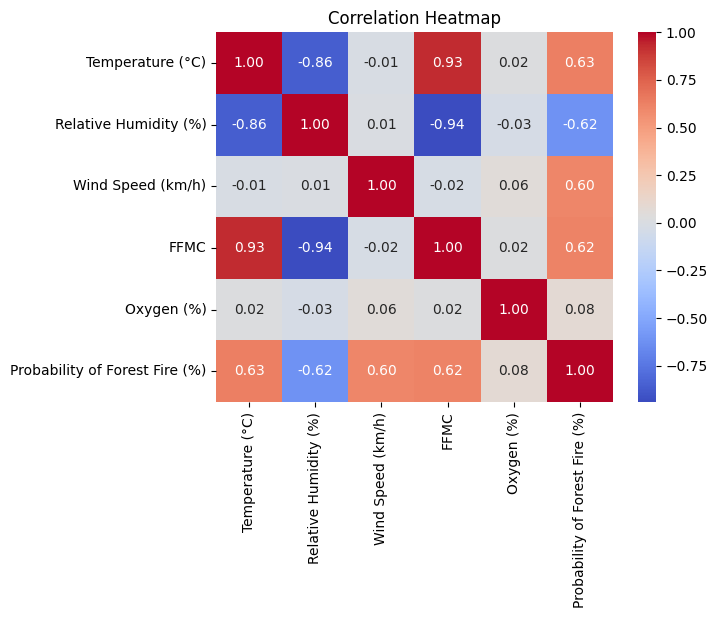

In [79]:
# Compute correlation matrix for numerical features
numerical_features = ['Temperature (°C)', 'Relative Humidity (%)', 'Wind Speed (km/h)', 
                      'FFMC', 'Oxygen (%)', 'Probability of Forest Fire (%)']
corr_matrix = Fire_detection_data[numerical_features].corr()

# Plot heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()


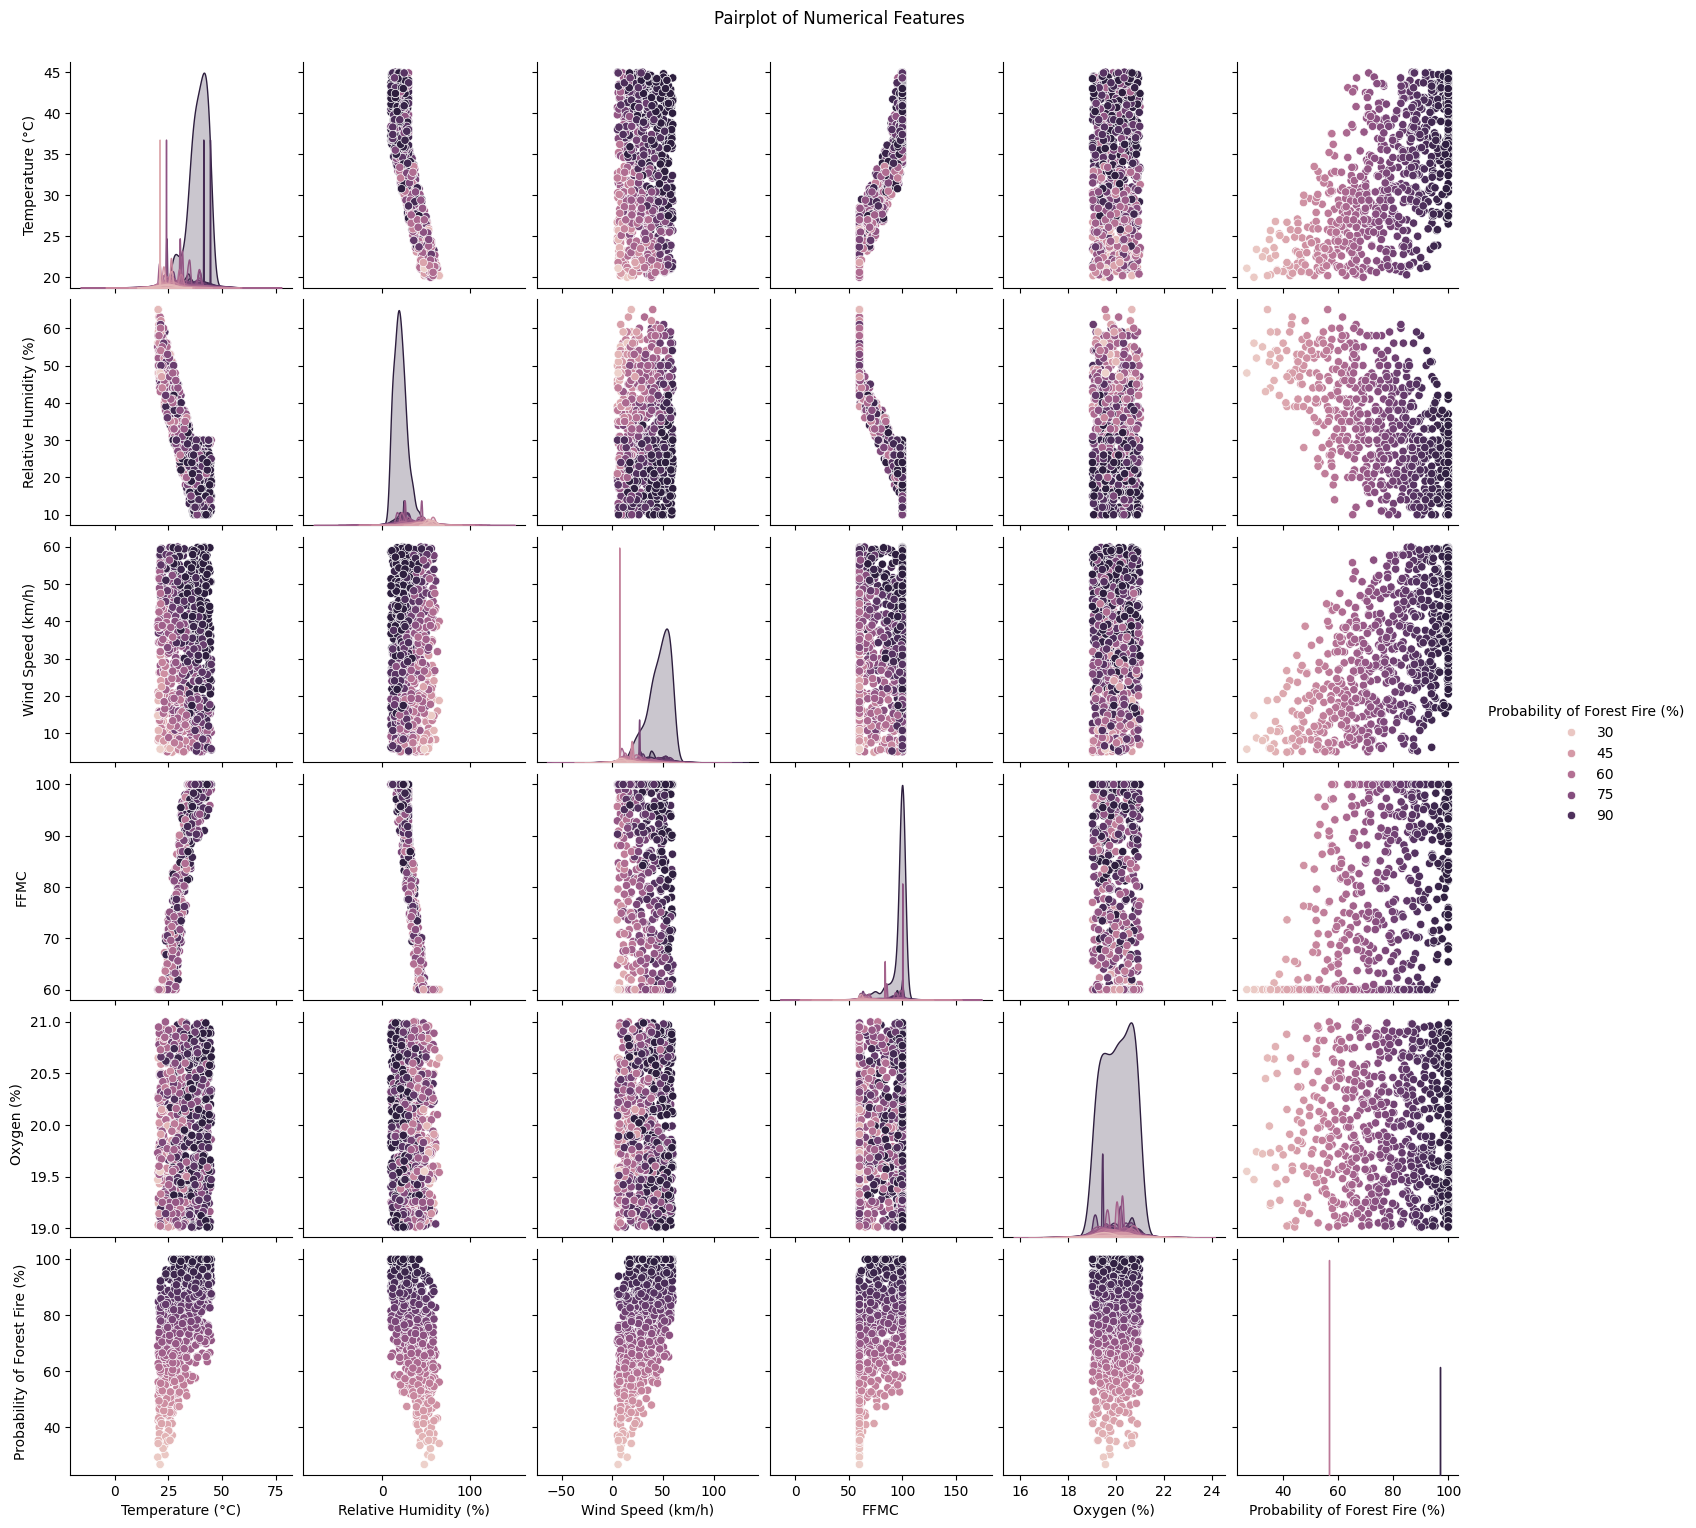

In [80]:
# Pairplot for numerical features with hue based on fire probability
sns.pairplot(Fire_detection_data, vars=numerical_features, diag_kind='kde', 
             hue='Probability of Forest Fire (%)')
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()


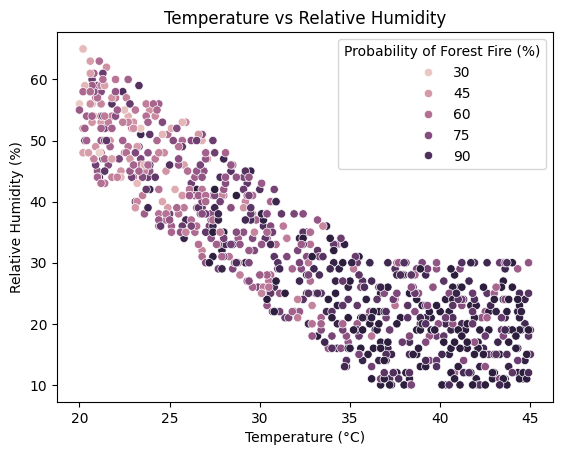

In [81]:
sns.scatterplot(x='Temperature (°C)', y='Relative Humidity (%)', 
                hue='Probability of Forest Fire (%)', data=Fire_detection_data)
plt.title('Temperature vs Relative Humidity')
plt.show()


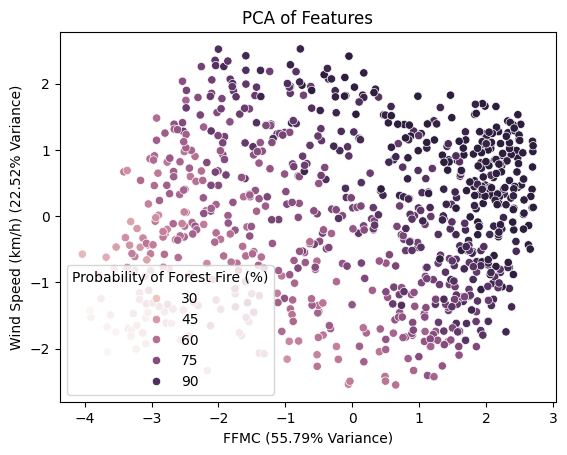

In [82]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Select and scale numerical features
features = Fire_detection_data[numerical_features]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Perform PCA
pca = PCA(n_components=2)
components = pca.fit_transform(scaled_features)

# Get feature names
feature_names = numerical_features

# Find the most important feature (highest absolute value) for each principal component
pc1_most_important_feature = feature_names[np.argmax(np.abs(pca.components_[0]))]
pc2_most_important_feature = feature_names[np.argmax(np.abs(pca.components_[1]))]

# Scatter plot for PCA components
sns.scatterplot(x=components[:, 0], y=components[:, 1], 
                hue=Fire_detection_data['Probability of Forest Fire (%)'])
plt.title('PCA of Features')

# Use the explained variance ratio to label components with more meaningful names
explained_variance = pca.explained_variance_ratio_

# Create custom labels for the principal components
plt.xlabel(f'{pc1_most_important_feature} ({explained_variance[0]*100:.2f}% Variance)')
plt.ylabel(f'{pc2_most_important_feature} ({explained_variance[1]*100:.2f}% Variance)')

plt.show()


C:\Users\Administrator\AppData\Local\Temp\ipykernel_12092\3684497712.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x_train['Temperature (°C)'], label='Train', shade=True)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_12092\3684497712.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x_val['Temperature (°C)'], label='Validation', shade=True)


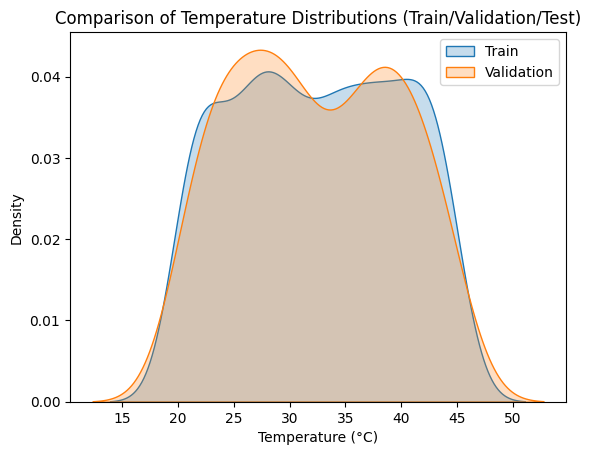

In [83]:
# Replace df_train, df_val, df_test with respective splits
sns.kdeplot(x_train['Temperature (°C)'], label='Train', shade=True)
sns.kdeplot(x_val['Temperature (°C)'], label='Validation', shade=True)

plt.title('Comparison of Temperature Distributions (Train/Validation/Test)')
plt.legend()
plt.show()


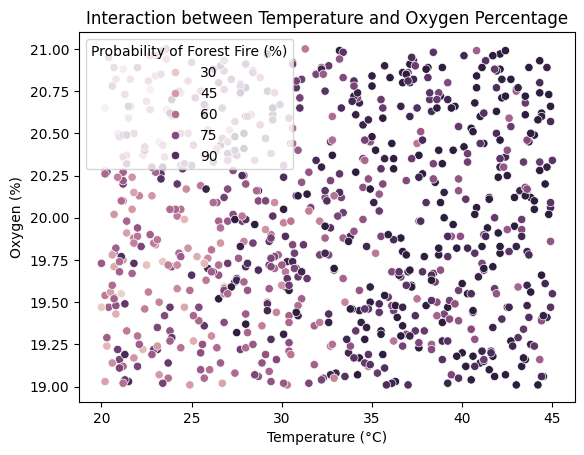

In [84]:
sns.scatterplot(x='Temperature (°C)', y='Oxygen (%)', 
                hue='Probability of Forest Fire (%)', data=Fire_detection_data)
plt.title('Interaction between Temperature and Oxygen Percentage')
plt.show()


C:\Users\Administrator\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


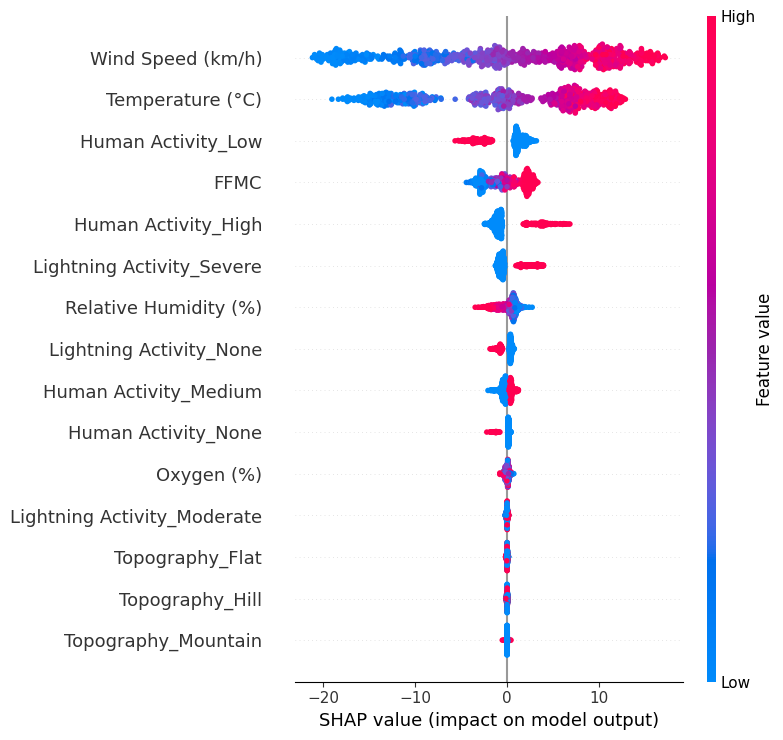

In [85]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(x)

shap.summary_plot(shap_values, x)


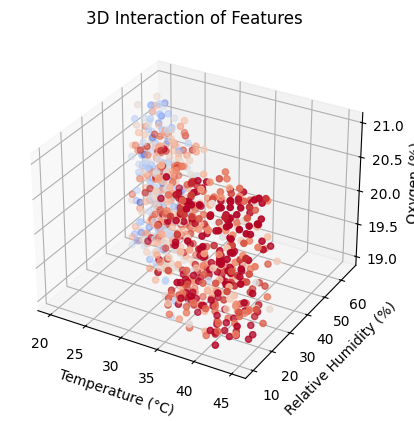

In [86]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(Fire_detection_data['Temperature (°C)'], 
           Fire_detection_data['Relative Humidity (%)'], 
           Fire_detection_data['Oxygen (%)'], 
           c=Fire_detection_data['Probability of Forest Fire (%)'], cmap='coolwarm')
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Relative Humidity (%)')
ax.set_zlabel('Oxygen (%)')
plt.title('3D Interaction of Features')
plt.show()


In [87]:
def pre_processing(test_data,file_name):
    test_data=pd.read_csv(file_name)
    test_data=one_hot_encoding(test_data,"Topography")
    test_data=one_hot_encoding(test_data,"Lightning Activity")
    test_data=one_hot_encoding(test_data,"Human Activity")
    return test_data
test_data=pd.DataFrame()
test_data=pre_processing(test_data,"final.csv")




    Topography_Flat  Topography_Hill  Topography_Mountain
0               1.0              0.0                  0.0
1               0.0              1.0                  0.0
2               0.0              0.0                  1.0
3               0.0              1.0                  0.0
4               1.0              0.0                  0.0
..              ...              ...                  ...
95              1.0              0.0                  0.0
96              0.0              0.0                  1.0
97              0.0              0.0                  1.0
98              1.0              0.0                  0.0
99              0.0              0.0                  1.0

[100 rows x 3 columns]
    Lightning Activity_Moderate  Lightning Activity_Severe  \
0                           1.0                        0.0   
1                           1.0                        0.0   
2                           0.0                        0.0   
3                           1.0 

In [90]:
print(test_data.head())

   Temperature (°C)  Relative Humidity (%)  Wind Speed (km/h)       FFMC  \
0         31.910119                     41          33.901231  88.228184   
1         38.764029                     36           4.108211  80.466483   
2         42.323631                     45          30.917806  84.220689   
3         20.942939                     29          50.190504  86.803020   
4         32.924987                     23          59.195996  73.126833   

   Oxygen (%)  Topography_Flat  Topography_Hill  Topography_Mountain  \
0   19.147040              1.0              0.0                  0.0   
1   20.931119              0.0              1.0                  0.0   
2   19.909122              0.0              0.0                  1.0   
3   20.624642              0.0              1.0                  0.0   
4   20.728751              1.0              0.0                  0.0   

   Lightning Activity_Moderate  Lightning Activity_Severe  \
0                          1.0                   

In [98]:
model.predict(test_data)

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- Human Activity_nan
- Lightning Activity_nan
Feature names seen at fit time, yet now missing:
- Human Activity_None
- Lightning Activity_None


In [92]:
import pickle
pickle.dump(model, open('forestModel.pkl', 'wb'))

In [96]:
model1=pickle.load(open('forestModel.pkl', 'rb'))

In [97]:
model1.predict(x_val)

array([ 55.84 ,  67.786,  48.13 ,  66.867,  86.596,  69.524,  41.473,
        48.407,  69.994,  98.536,  48.318,  82.458,  96.997,  95.093,
        71.642,  92.396,  81.541,  63.169,  63.695,  68.536,  86.325,
        99.456,  97.776,  77.193,  94.563,  76.964,  81.955,  78.994,
        90.588,  87.813,  80.169,  98.428,  70.466,  88.662,  56.471,
        94.231,  80.226,  66.795,  96.246,  58.493,  77.063,  71.549,
        98.247,  53.844,  98.461,  65.083,  78.3  ,  94.977,  88.789,
        67.092,  97.983,  97.585,  77.558,  89.021,  47.07 ,  84.948,
        63.394,  91.608,  52.572,  88.319,  94.895,  98.946,  93.907,
        68.918,  69.743,  85.973,  44.352,  79.002,  60.306,  98.938,
        87.569,  69.102,  45.862,  85.535,  93.592,  59.874,  68.835,
        67.687,  82.575,  74.23 ,  99.574,  82.049,  76.766,  80.254,
        99.925,  64.645,  65.28 ,  92.413, 100.   ,  94.247,  74.949,
        82.47 ,  96.28 ,  48.957,  61.449,  87.238,  73.978,  65.211,
        88.51 ,  93.

In [99]:
print(x_val)

     Temperature (°C)  Relative Humidity (%)  Wind Speed (km/h)   FFMC  \
696              32.1                     21                5.1   95.7   
667              42.6                     21                8.2  100.0   
63               24.8                     45                5.2   60.0   
533              28.0                     34               10.9   75.2   
66               30.6                     36               46.8   79.7   
..                ...                    ...                ...    ...   
589              34.6                     19               18.7  100.0   
798              37.4                     12               10.8  100.0   
744              41.0                     24                8.5  100.0   
513              36.9                     22               43.8   94.2   
670              38.6                     25               32.7   94.2   

     Oxygen (%)  Topography_Flat  Topography_Hill  Topography_Mountain  \
696       19.38              0.0     